# 🛰️ SCRAP v4 — Maximised F₂ Score: Full ESA Pipeline Fix
### Team: Mahmoud Alyosify · Mohamed Yahya · Mirna Embaby | Queen's University CSAI 801

---

## What v3 Got Wrong → What v4 Fixes

| v3 Bug / Weakness | v4 Fix |
|---|---|
| `XGBoostError`: inf values crash QuantileDMatrix | Median imputation fit on train-only, applied everywhere |
| `SyntaxError` in summary cell | All triple-quote strings corrected |
| sesc grid search optimises ESA Loss → overfits 13 val HR events | Sweep optimises **F₂ directly** on combined train+val |
| Anomaly detector never trains (XGB crash blocks it) | Dedicated XGB binary classifier with `scale_pos_weight` |
| Δr regression uses val-optimised LightGBM (too complex) | Paper hyperparams (n=25, ff=0.25) + soft-blend override |
| No physics-informed features beyond raw CDM columns | 6 new features: risk velocity, covariance volume, etc. |
| Hard threshold on anomaly prediction | **Soft probabilistic blending** using anomaly score p |

## Architecture — 5 Layers Applied in Order

```
Layer 1 → LRP Baseline:        r̂ = r₋₂ (high-risk), −6.001 (low-risk)       → ~0.694
Layer 2 → sesc Cascade:        promote borderline low-risk events (paper thresholds)
Layer 3 → Anomaly Classifier:  XGBoost catches low→high transitions (Magpies)  
Layer 4 → Δr Regression:       LightGBM (n=25) refines MSEHR on high-risk events
Layer 5 → Soft Blend:          p_anom × Δr_pred + (1−p_anom) × sesc_pred
```

## Leaderboard Reference (Uriot et al. 2020, Table 3)

| Team | Score | MSEHR | F₂ |
|---|---|---|---|
| LRP Baseline | 0.694 | 0.513 | 0.739 |
| **sesc (Winner)** | **0.556** | **0.407** | **0.733** |
| dietmarw (2nd) | 0.571 | 0.437 | 0.765 |
| Magpies (3rd) | 0.585 | 0.441 | **0.753** |
| 🎯 v4 Target | **≤ 0.54** | ≤ 0.42 | **≥ 0.75** |

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 1 — Install Dependencies                              ║
# ╚══════════════════════════════════════════════════════════════╝
import subprocess, sys
for pkg in ["datasets", "lightgbm", "xgboost", "scikit-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)
print("✅ All packages ready")

✅ All packages ready


In [2]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 2 — Imports & Global Constants                        ║
# ╚══════════════════════════════════════════════════════════════╝
import warnings, logging
from typing import Dict, Optional, Tuple, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import fbeta_score, roc_auc_score
import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("SCRAP_v4")
np.random.seed(42)

# ── ESA Challenge Constants (from paper) ──────────────────────────────────────
LOG_THR  = -6.0      # High-risk boundary: log10(1e-6)
CLIP_LOW = -6.001    # Clip ALL low-risk predictions here (paper Section 4.3 trick)
EPS      = 1e-12

# ── ESA Eligibility Constraints (paper Section 4.2) ──────────────────────────
FEAT_MIN_TCA = 2.0   # Feature CDMs: time_to_tca >= 2.0 days
TGT_MAX_TCA  = 1.0   # Target CDM:   time_to_tca <  1.0 day

print("✅ Setup complete")
print(f"   High-risk threshold : 10^{LOG_THR:.0f} = 1e-6")
print(f"   Low-risk clip value : {CLIP_LOW}  (paper trick: minimises MSEHR for FN)")
print(f"   Feature CDM window  : time_to_tca >= {FEAT_MIN_TCA} days")
print(f"   Target CDM window   : time_to_tca <  {TGT_MAX_TCA} day")

✅ Setup complete
   High-risk threshold : 10^-6 = 1e-6
   Low-risk clip value : -6.001  (paper trick: minimises MSEHR for FN)
   Feature CDM window  : time_to_tca >= 2.0 days
   Target CDM window   : time_to_tca <  1.0 day


In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 3 — Load Raw CDM Data from HuggingFace               ║
# ╚══════════════════════════════════════════════════════════════╝
# Each row = one Conjunction Data Message (CDM).
# Multiple CDMs per conjunction event, ordered in time.

def load_raw() -> pd.DataFrame:
    log.info("Loading mahmoudalyosify/SCRAP from HuggingFace…")
    ds  = load_dataset("mahmoudalyosify/SCRAP", split="train")
    df  = pd.DataFrame(ds)
    # Convert all columns (except event_id) to numeric
    for c in df.columns:
        if c != "event_id":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    log.info(f"Loaded: {len(df):,} CDMs | {df['event_id'].nunique():,} events | {df.shape[1]} cols")
    return df

raw = load_raw()

print(f"\n{'─'*58}")
print(f"  CDMs total            : {len(raw):,}")
print(f"  Unique events         : {raw['event_id'].nunique():,}")
print(f"  Avg CDMs/event        : {len(raw)/raw['event_id'].nunique():.1f}")
print(f"  time_to_tca range     : [{raw['time_to_tca'].min():.2f}, {raw['time_to_tca'].max():.2f}] days")
print(f"  risk range (log10)    : [{raw['risk'].min():.1f}, {raw['risk'].max():.1f}]")
print(f"{'─'*58}")
raw.head(3)

2026-03-02 02:06:41,524 [INFO] Loading mahmoudalyosify/SCRAP from HuggingFace…
2026-03-02 02:06:42,223 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/mahmoudalyosify/SCRAP/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-03-02 02:06:42,223 [WARNING] Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
2026-03-02 02:06:42,240 [INFO] HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/mahmoudalyosify/SCRAP/350b5307ed29ccd086a2439cfde238cf8f581c46/README.md "HTTP/1.1 200 OK"
2026-03-02 02:06:42,390 [INFO] HTTP Request: HEAD https://huggingface.co/datasets/mahmoudalyosify/SCRAP/resolve/350b5307ed29ccd086a2439cfde238cf8f581c46/SCRAP.py "HTTP/1.1 404 Not Found"
2026-03-02 02:06:44,868 [INFO] HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/mahmoudalyosify/SCRAP/mahmoudalyosify/SCRAP.py "HTTP/1.1 404 Not Found"
2026-03-02 02:06:45,1


──────────────────────────────────────────────────────────
  CDMs total            : 162,634
  Unique events         : 13,154
  Avg CDMs/event        : 12.4
  time_to_tca range     : [-0.15, 6.99] days
  risk range (log10)    : [-30.0, -1.4]
──────────────────────────────────────────────────────────


,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.566798,5,-10.204955,-7.834756,8.602101,14923.0,13792.0,453.8,5976.6,...,0.147350,58.272095,0.004092,0.165044,0.002987,0.386462,89.0,83.0,42.0,11.0
1,0,1.207494,5,-10.355758,-7.848937,8.956374,14544.0,13792.0,474.3,5821.2,...,0.059672,57.966413,0.003753,0.164383,0.002933,0.386393,89.0,83.0,42.0,11.0
2,0,0.952193,5,-10.345631,-7.847406,8.932195,14475.0,13792.0,474.6,5796.2,...,0.039258,57.907599,0.003576,0.164352,0.002967,0.386381,89.0,83.0,42.0,11.0


In [4]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 4 — Build Event Table (One Row Per Event)             ║
# ╚══════════════════════════════════════════════════════════════╝
#
# KEY PAPER FINDING (Section 6, Uriot et al. 2020):
#   Training data = "a table of 8293 CDMs, from as many events, each described
#   by 100 features" — ONE CDM per event (the last feature CDM).
#   NO time-series aggregation in the competition-winning approach.
#
# We add a SMALL set of temporal statistics (mean/std/trend of risk) because:
#   (a) They provide signal about the trajectory of risk over time
#   (b) They are computed only from FEATURE CDMs (time_to_tca >= 2 days)
#       so they do NOT leak future information.
#
# v4 NEW PHYSICS-INFORMED FEATURES:
#   risk_velocity   = rate of change of risk over recent CDMs (risk drift)
#   risk_range      = max_risk - mean_risk (spread of risk estimates)
#   cov_vol_t       = log(σ_r * σ_t * σ_n) for target   (covariance volume)
#   cov_vol_c       = log(σ_r * σ_t * σ_n) for chaser   (covariance volume)
#   cov_vol_ratio   = cov_vol_t - cov_vol_c               (asymmetry)
#   borderline_prox = r₋₂ - LOG_THR  (negative = how far below threshold)

def build_event_table(df: pd.DataFrame) -> pd.DataFrame:
    """
    One row per conjunction event.
    Features = all numerical columns from LAST feature CDM (time_to_tca >= 2)
              plus temporal statistics and physics-informed engineered features.
    Target   = risk from the CDM closest to TCA.
    """
    log.info(f"Building event table from {df['event_id'].nunique():,} events…")
    records = []

    for eid, grp in df.groupby("event_id", sort=False):
        feat_cdms = grp[grp["time_to_tca"] >= FEAT_MIN_TCA]
        tgt_cdms  = grp[grp["time_to_tca"] <  TGT_MAX_TCA]

        if len(feat_cdms) == 0:
            continue   # no CDM >= 2 days → skip event

        # ── Last feature CDM = CDM closest to TCA among feature CDMs ───────────
        last_feat = feat_cdms.loc[feat_cdms["time_to_tca"].idxmin()]

        # ── Target = CDM closest to TCA (can be < 1 day before TCA) ────────────
        final_cdm = grp.loc[grp["time_to_tca"].idxmin()]
        y_final   = float(final_cdm["risk"])
        r_minus2  = float(last_feat["risk"])

        # ── Temporal risk statistics (from ALL feature CDMs, sorted by time_to_tca) ─
        risk_seq = feat_cdms.sort_values("time_to_tca", ascending=False)["risk"].values
        n_feat   = len(feat_cdms)
        tca_last = float(last_feat["time_to_tca"])

        mean_risk  = float(feat_cdms["risk"].mean())
        std_risk   = float(feat_cdms["risk"].std()) if n_feat > 1 else 0.0
        max_risk   = float(feat_cdms["risk"].max())
        trend_risk = float(risk_seq[-1] - risk_seq[0]) if n_feat > 1 else 0.0  # negative = rising

        # ── v4: Physics-Informed Engineered Features ────────────────────────────
        # risk_velocity: average rate of risk change per day (negative = rising toward 0)
        time_span_feat = float(feat_cdms["time_to_tca"].max() - tca_last)
        risk_velocity  = trend_risk / max(time_span_feat, 0.1)

        # risk_range: spread of risk estimates (high = uncertain trajectory)
        risk_range = max_risk - mean_risk

        # covariance volume: proxy for 3D position uncertainty volume
        # V ∝ σ_r × σ_t × σ_n  (in log-space: log V = log σ_r + log σ_t + log σ_n)
        def safe_log_cov_vol(row, prefix):
            sr = float(row.get(f"{prefix}_sigma_r",  np.nan))
            st = float(row.get(f"{prefix}_sigma_t",  np.nan))
            sn = float(row.get(f"{prefix}_sigma_n",  np.nan))
            if any(np.isnan([sr, st, sn])) or any(v <= 0 for v in [sr, st, sn]):
                return np.nan
            return np.log10(sr * st * sn)

        cov_vol_t = safe_log_cov_vol(last_feat, "t")
        cov_vol_c = safe_log_cov_vol(last_feat, "c")
        cov_vol_ratio = (cov_vol_t - cov_vol_c) if not any(np.isnan([cov_vol_t, cov_vol_c])) else np.nan

        # borderline_proximity: how far r₋₂ is from the high-risk threshold
        # = 0 at the threshold, negative when safely low-risk
        borderline_prox = r_minus2 - LOG_THR

        row = {
            # ── Meta ────────────────────────────────────────────────────────
            "event_id"        : eid,
            "eligible"        : (len(tgt_cdms) > 0),
            # ── Targets ─────────────────────────────────────────────────────
            "y_final"         : y_final,
            "r_minus2"        : r_minus2,
            "delta_r"         : y_final - r_minus2,
            # ── Temporal Statistics ──────────────────────────────────────────
            "n_cdms"          : n_feat,
            "tca_last"        : tca_last,
            "mean_risk"       : mean_risk,
            "std_risk"        : std_risk,
            "max_risk"        : max_risk,
            "trend_risk"      : trend_risk,
            # ── v4 Physics Features ──────────────────────────────────────────
            "risk_velocity"   : risk_velocity,
            "risk_range"      : risk_range,
            "cov_vol_t"       : cov_vol_t,
            "cov_vol_c"       : cov_vol_c,
            "cov_vol_ratio"   : cov_vol_ratio,
            "borderline_prox" : borderline_prox,
        }

        # ── Copy ALL numerical CDM columns from the last feature CDM ────────
        skip = {"event_id", "time_to_tca"}
        for col in last_feat.index:
            if col in skip or col in row:
                continue
            try:
                row[col] = float(last_feat[col])
            except (ValueError, TypeError):
                pass

        records.append(row)

    out  = pd.DataFrame(records)
    elig = out[out["eligible"]].copy()
    hr   = (elig["y_final"] >= LOG_THR).sum()
    log.info(f"Total events: {len(out):,} | Eligible: {len(elig):,} | High-risk: {hr}")
    return out

event_df = build_event_table(raw)

elig = event_df[event_df["eligible"]].copy()
hr   = (elig["y_final"] >= LOG_THR)
print(f"\n{'─'*58}")
print(f"  Total events            : {len(event_df):,}")
print(f"  Eligible events         : {len(elig):,}")
print(f"  High-risk eligible      : {hr.sum()} ({100*hr.mean():.2f}%)")
print(f"  Low-risk eligible       : {(~hr).sum()}")
print(f"  Imbalance ratio         : 1 high : {(~hr).sum()//max(hr.sum(),1)} low")
print(f"  r₋₂ range (log10)       : [{elig['r_minus2'].min():.1f}, {elig['r_minus2'].max():.1f}]")
print(f"  delta_r range           : [{elig['delta_r'].min():.2f}, {elig['delta_r'].max():.2f}]")
print(f"  Features per event      : {event_df.shape[1]}")
print(f"{'─'*58}")
event_df.head(3)

2026-03-02 02:09:05,548 [INFO] Building event table from 13,154 events…
2026-03-02 02:10:01,039 [INFO] Total events: 11,942 | Eligible: 8,293 | High-risk: 66



──────────────────────────────────────────────────────────
  Total events            : 11,942
  Eligible events         : 8,293
  High-risk eligible      : 66 (0.80%)
  Low-risk eligible       : 8227
  Imbalance ratio         : 1 high : 124 low
  r₋₂ range (log10)       : [-30.0, -1.8]
  delta_r range           : [-28.17, 23.91]
  Features per event      : 118
──────────────────────────────────────────────────────────


,event_id,eligible,y_final,r_minus2,delta_r,n_cdms,tca_last,mean_risk,std_risk,max_risk,...,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,1,False,-9.248105,-9.248105,0.0,4,3.570013,-8.386902,1.035374,-7.422508,...,0.124802,30.242768,0.005883,0.174956,0.003408,0.058311,71.0,87.0,21.0,5.0
1,2,True,-30.000000,-30.000000,0.0,14,2.340627,-27.261902,6.960126,-10.816161,...,0.033330,3.039035,0.004753,0.053199,0.003115,0.194275,69.0,77.0,11.0,6.0
2,3,True,-30.000000,-30.000000,0.0,15,2.278941,-20.422318,10.598401,-9.412177,...,0.095417,3.976678,0.008990,0.056902,0.007782,0.160887,68.0,70.0,0.0,7.0


In [5]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 5 — ESA Scoring Metric (Official)                    ║
# ╚══════════════════════════════════════════════════════════════╝
#
# L(r̂) = MSEHR / F₂    (LOWER IS BETTER)
#
# MSEHR = MSE computed ONLY over true high-risk events (r_true >= 10^-6)
# F₂    = F-beta score (β=2) treating high/low as binary classification
#
# β=2 means FALSE NEGATIVES are penalised 4× more than false positives.
# → Recall matters far more than Precision for this metric.
#
# PAPER TRICK (Section 4.3): All low-risk predictions MUST be clipped to -6.001.
# This minimises MSEHR for false negatives: (r_true − (−6.001))² is much smaller
# than (r_true − (−30))² for any r_true ≥ -6.

def clip_low_risk(y_pred: np.ndarray) -> np.ndarray:
    """Clip all predictions below LOG_THR to CLIP_LOW (= -6.001)."""
    out = np.asarray(y_pred, dtype=float).copy()
    out[out < LOG_THR] = CLIP_LOW
    return out

def esa_loss(y_true: np.ndarray, y_pred: np.ndarray,
             apply_clip: bool = True) -> Dict:
    """
    Compute the official ESA Collision Avoidance Challenge metric.
    Returns dict: {loss, f2, precision, recall, mse_hr, tp, fp, fn, tn, n_hr}
    """
    if apply_clip:
        y_pred = clip_low_risk(y_pred)

    y_t = (y_true >= LOG_THR).astype(int)
    y_p = (y_pred >= LOG_THR).astype(int)

    tp = int(np.sum((y_p == 1) & (y_t == 1)))
    fp = int(np.sum((y_p == 1) & (y_t == 0)))
    fn = int(np.sum((y_p == 0) & (y_t == 1)))
    tn = int(np.sum((y_p == 0) & (y_t == 0)))

    prec = tp / (tp + fp + EPS)
    rec  = tp / (tp + fn + EPS)
    b2   = 4.0   # β = 2  →  β² = 4
    f2   = (1 + b2) * prec * rec / (b2 * prec + rec + EPS)

    hr     = (y_true >= LOG_THR)
    mse_hr = float(np.mean((y_true[hr] - y_pred[hr])**2)) if hr.sum() > 0 else 0.0
    loss   = mse_hr / (f2 + EPS) if f2 > 0 else float("inf")

    return dict(loss=loss, f2=f2, precision=prec, recall=rec,
                mse_hr=mse_hr, tp=tp, fp=fp, fn=fn, tn=tn,
                n_hr=int(hr.sum()), n_total=len(y_true))


def show(m: Dict, name: str) -> None:
    """Pretty-print ESA loss report."""
    bar = "=" * 62
    print(f"\n{bar}")
    print(f"  {name}")
    print(bar)
    print(f"  ESA LOSS (L = MSEHR/F₂) : {m['loss']:.6f}  ← LOWER IS BETTER")
    print(f"  {'─'*54}")
    print(f"  F₂-Score               : {m['f2']:.4f}  (max 1.0)")
    print(f"  Precision              : {m['precision']:.4f}")
    print(f"  Recall                 : {m['recall']:.4f}  ← most critical")
    print(f"  MSEHR (high-risk MSE)  : {m['mse_hr']:.4f}")
    print(f"  {'─'*54}")
    print(f"  TP (correctly caught)  : {m['tp']}")
    print(f"  FP (false alarms)      : {m['fp']}")
    print(f"  FN (MISSED ⚠️)         : {m['fn']}")
    print(f"  TN (correctly safe)    : {m['tn']}")
    print(f"  High-risk total        : {m['n_hr']} / {m['n_total']}")
    print(bar)


print("✅ ESA scoring functions defined")
print("   L = MSEHR / F₂ | Paper target scores:")
print("   LRP baseline = 0.6940 | sesc winner = 0.5560 | Vidente = 0.5467")

✅ ESA scoring functions defined
   L = MSEHR / F₂ | Paper target scores:
   LRP baseline = 0.6940 | sesc winner = 0.5560 | Vidente = 0.5467


In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 6 — Stratified Train / Val / Test Split               ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Strategy: 60% train | 20% val | 20% test
# Stratified by binary high-risk label to preserve class ratio.
# v4 FIX: NaN imputation uses TRAIN medians only (no data leakage).

elig_df = event_df[event_df["eligible"]].copy().reset_index(drop=True)
y_all   = elig_df["y_final"].values
strat   = (y_all >= LOG_THR).astype(int)

idx     = np.arange(len(elig_df))
i_tmp, i_test = train_test_split(idx, test_size=0.20, random_state=42, stratify=strat)
i_train, i_val = train_test_split(
    i_tmp, test_size=0.25, random_state=42, stratify=strat[i_tmp]
)

train_df = elig_df.iloc[i_train].reset_index(drop=True)
val_df   = elig_df.iloc[i_val].reset_index(drop=True)
test_df  = elig_df.iloc[i_test].reset_index(drop=True)

print("Split summary:")
for nm, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    hr = (df["y_final"] >= LOG_THR).sum()
    print(f"  {nm:5s}: {len(df):5,} events | high-risk: {hr:4d} ({100*hr/len(df):.1f}%)")

# ── Feature columns for ML models ─────────────────────────────────────────────
META = {"event_id", "eligible", "y_final", "r_minus2", "delta_r",
        "n_cdms", "tca_last", "mean_risk", "std_risk", "max_risk",
        "trend_risk"}
FEAT = [c for c in elig_df.columns if c not in META]

# ── v4 FIX: Proper NaN / Inf imputation ───────────────────────────────────────
# Compute TRAIN medians ONLY, then apply to val and test.
# This prevents any information leakage from the future.
def get_clean_X(df: pd.DataFrame, cols: List[str],
                impute_medians: Optional[pd.Series] = None) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Extract feature matrix with full NaN/Inf cleaning.
    Returns (X_clean, medians_used) — medians can be passed back for val/test.
    """
    valid = [c for c in cols if c in df.columns]
    X = df[valid].copy()

    # Replace inf/−inf with NaN before median imputation
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Compute or apply median imputation
    if impute_medians is None:
        medians = X.median()
    else:
        medians = impute_medians

    X.fillna(medians, inplace=True)

    # Clip extreme values to ±1e9 to prevent numerical issues
    X = X.clip(-1e9, 1e9)

    return X, medians

# Build feature matrices
X_train_raw, train_medians = get_clean_X(train_df, FEAT)
X_val_raw,   _             = get_clean_X(val_df,   FEAT, train_medians)
X_test_raw,  _             = get_clean_X(test_df,  FEAT, train_medians)
COLS = list(X_train_raw.columns)

# Extract arrays
X_train = X_train_raw.values
X_val   = X_val_raw.values
X_test  = X_test_raw.values

y_train  = train_df["y_final"].values
y_val    = val_df["y_final"].values
y_test   = test_df["y_final"].values

r2_train = train_df["r_minus2"].values
r2_val   = val_df["r_minus2"].values
r2_test  = test_df["r_minus2"].values

dr_train = train_df["delta_r"].values
dr_val   = val_df["delta_r"].values
dr_test  = test_df["delta_r"].values

print(f"\n  Feature matrix : {X_train.shape[1]} columns")
print(f"  NaN remaining  : {np.isnan(X_train).sum()} (should be 0)")
print(f"  Inf remaining  : {np.isinf(X_train).sum()} (should be 0)")
print(f"  New physics features: {[c for c in COLS if c in ['risk_velocity','risk_range','cov_vol_t','cov_vol_c','cov_vol_ratio','borderline_prox']]}")

Split summary:
  Train: 4,975 events | high-risk:   40 (0.8%)
  Val  : 1,659 events | high-risk:   13 (0.8%)
  Test : 1,659 events | high-risk:   13 (0.8%)

  Feature matrix : 107 columns
  NaN remaining  : 4975 (should be 0)
  Inf remaining  : 0 (should be 0)
  New physics features: ['risk_velocity', 'risk_range', 'cov_vol_t', 'cov_vol_c', 'cov_vol_ratio', 'borderline_prox']


In [7]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 7 — Layer 1: LRP Baseline (Latest Risk Prediction)   ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Paper Section 4.4:
#   r̂ = r₋₂        if r₋₂ >= -6   (already high-risk → keep it)
#   r̂ = -6.001     if r₋₂ <  -6   (low-risk → clip to -6.001)
#
# Paper reports score = 0.694 on the full test set.
# This is the foundation that ALL other layers build upon.

def lrp_predict(r_minus2: np.ndarray) -> np.ndarray:
    """Layer 1: Latest Risk Prediction baseline."""
    pred = r_minus2.copy().astype(float)
    pred[pred < LOG_THR] = CLIP_LOW
    return pred

lrp_val  = esa_loss(y_val,  lrp_predict(r2_val),  apply_clip=False)
lrp_test = esa_loss(y_test, lrp_predict(r2_test), apply_clip=False)

show(lrp_test, "LAYER 1 — LRP Baseline")
print(f"\n  Validation LRP loss: {lrp_val['loss']:.4f}")
print(f"  (Paper reports 0.694 on full ESA test set)")


  LAYER 1 — LRP Baseline
  ESA LOSS (L = MSEHR/F₂) : 1.228414  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.3271  (max 1.0)
  Precision              : 0.1273
  Recall                 : 0.5385  ← most critical
  MSEHR (high-risk MSE)  : 0.4018
  ──────────────────────────────────────────────────────
  TP (correctly caught)  : 7
  FP (false alarms)      : 48
  FN (MISSED ⚠️)         : 6
  TN (correctly safe)    : 1598
  High-risk total        : 13 / 1659

  Validation LRP loss: 1.2189
  (Paper reports 0.694 on full ESA test set)


In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 8 — Layer 2: sesc Cascade (Paper Winner)             ║
# ╚══════════════════════════════════════════════════════════════╝
#
# From paper Equation (2) and Section 5.3.1:
#
# KEY INSIGHT: Most false negatives (missed high-risk events) have r₋₂ just
# BELOW -6.0. They look safe but turn out risky at TCA.
# sesc PROMOTES these borderline events to high-risk to boost Recall.
#
# v4 IMPROVEMENT: We optimise the promotion window thresholds by maximising
# F₂ directly on the COMBINED train+val set (avoids overfitting to 13 val events).
# Safety filters (c_object_type, t_span, miss_distance) are ALWAYS applied.

def get_col(df: pd.DataFrame, names: List[str]) -> Optional[np.ndarray]:
    """Try multiple candidate column names, return first match."""
    for n in names:
        if n in df.columns:
            return df[n].values
    return None

def sesc_cascade(
    r_minus2   : np.ndarray,
    c_obj_type : Optional[np.ndarray] = None,
    t_span     : Optional[np.ndarray] = None,
    miss_dist  : Optional[np.ndarray] = None,
    # Promotion windows
    s0_lo=-6.04, s0_pred=-5.95,   # near threshold: promote
    s1_lo=-6.40, s1_pred=-5.60,   # borderline: promote
    s2_lo=-7.30, s2_pred=-5.00,   # deep borderline: promote
) -> np.ndarray:
    pred = lrp_predict(r_minus2).copy()

    # Apply promotions (lower priority first, higher priority overwrites)
    m2 = (r_minus2 >= s2_lo) & (r_minus2 < s1_lo)
    pred[m2] = s2_pred
    m1 = (r_minus2 >= s1_lo) & (r_minus2 < s0_lo)
    pred[m1] = s1_pred
    m0 = (r_minus2 >= s0_lo) & (r_minus2 < LOG_THR)
    pred[m0] = s0_pred

    # Safety overrides — de-promote based on physical characteristics
    if c_obj_type is not None:
        is_payload = pd.Series(c_obj_type).astype(str).str.lower().str.contains(
            "payload", na=False).values
        pred[is_payload] = CLIP_LOW
    if t_span is not None:
        is_small = (pd.to_numeric(pd.Series(t_span), errors="coerce").fillna(999) < 0.5).values
        pred[is_small] = CLIP_LOW
    if miss_dist is not None:
        is_far = (pd.to_numeric(pd.Series(miss_dist), errors="coerce").fillna(0) > 30000).values
        pred[is_far] = CLIP_LOW

    # Clip extreme high-risk predictions (paper step 6)
    pred[(r_minus2 >= -4.00) & (r_minus2 < -3.50)] = -4.00
    pred[r_minus2 >= -3.50] = -3.50

    return pred


# ── v4: Optimise sesc thresholds by maximising F₂ on train+val ───────────────
# Use the COMBINED train+val to avoid overfitting to 13-event val sets.
# The optimisation target is F₂ (not ESA loss) because:
#   (a) F₂ is stable with more events
#   (b) Maximising recall is the key objective
print("Optimising sesc thresholds on train+val (maximise F₂)…")

# Combine train and val for calibration
r2_tv    = np.concatenate([r2_train, r2_val])
y_tv     = np.concatenate([y_train,  y_val])
tv_df    = pd.concat([train_df, val_df], ignore_index=True)
c_obj_tv = get_col(tv_df, ["c_object_type"])
t_sp_tv  = get_col(tv_df, ["t_span"])
md_tv    = get_col(tv_df, ["miss_distance"])

best_f2, best_params = -1.0, {}
for s2_lo in np.arange(-9.0, -6.5, 0.5):
    for s1_lo in np.arange(-7.5, s2_lo + 0.1, 0.25):
        for s0_lo in np.arange(-7.0, min(s1_lo + 0.1, -6.0), 0.25):
            for s2_pred in [-5.5, -5.0, -4.5]:
                for s1_pred in [-5.8, -5.6, -5.4]:
                    for s0_pred in [-5.95, -5.90, -5.80]:
                        if s2_lo >= s1_lo or s1_lo >= s0_lo:
                            continue
                        pred = sesc_cascade(
                            r2_tv, c_obj_tv, t_sp_tv, md_tv,
                            s0_lo=s0_lo, s0_pred=s0_pred,
                            s1_lo=s1_lo, s1_pred=s1_pred,
                            s2_lo=s2_lo, s2_pred=s2_pred,
                        )
                        y_t = (y_tv   >= LOG_THR).astype(int)
                        y_p = (pred   >= LOG_THR).astype(int)
                        f2  = fbeta_score(y_t, y_p, beta=2, zero_division=0)
                        if f2 > best_f2:
                            best_f2 = f2
                            best_params = dict(
                                s0_lo=s0_lo, s0_pred=s0_pred,
                                s1_lo=s1_lo, s1_pred=s1_pred,
                                s2_lo=s2_lo, s2_pred=s2_pred,
                            )

print(f"Best train+val F₂: {best_f2:.4f}")
print(f"  Optimal thresholds: {best_params}")

# Evaluate paper thresholds vs optimised thresholds on test set
sesc_paper_test  = sesc_cascade(r2_test,
    get_col(test_df, ["c_object_type"]),
    get_col(test_df, ["t_span"]),
    get_col(test_df, ["miss_distance"]))
sesc_tuned_test  = sesc_cascade(r2_test,
    get_col(test_df, ["c_object_type"]),
    get_col(test_df, ["t_span"]),
    get_col(test_df, ["miss_distance"]),
    **best_params)

m_sesc_paper = esa_loss(y_test, sesc_paper_test, apply_clip=False)
m_sesc_tuned = esa_loss(y_test, sesc_tuned_test, apply_clip=False)
show(m_sesc_paper, "LAYER 2 — sesc Cascade (Paper Thresholds)")
show(m_sesc_tuned, "LAYER 2 — sesc Cascade (F₂-Optimised Thresholds)")

# Pick whichever sesc achieves better val loss
sesc_paper_val = sesc_cascade(r2_val,
    get_col(val_df, ["c_object_type"]),
    get_col(val_df, ["t_span"]),
    get_col(val_df, ["miss_distance"]))
sesc_tuned_val = sesc_cascade(r2_val,
    get_col(val_df, ["c_object_type"]),
    get_col(val_df, ["t_span"]),
    get_col(val_df, ["miss_distance"]),
    **best_params)

if esa_loss(y_val, sesc_tuned_val, apply_clip=False)["f2"] >= \
   esa_loss(y_val, sesc_paper_val, apply_clip=False)["f2"]:
    best_sesc_params = best_params
    print("\n→ Using F₂-optimised sesc thresholds")
else:
    best_sesc_params = {}
    print("\n→ Using paper sesc thresholds (tuned params did not improve val F₂)")

Optimising sesc thresholds on train+val (maximise F₂)…
Best train+val F₂: -1.0000
  Optimal thresholds: {}

  LAYER 2 — sesc Cascade (Paper Thresholds)
  ESA LOSS (L = MSEHR/F₂) : 1.555930  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.2674  (max 1.0)
  Precision              : 0.0741
  Recall                 : 0.7692  ← most critical
  MSEHR (high-risk MSE)  : 0.4160
  ──────────────────────────────────────────────────────
  TP (correctly caught)  : 10
  FP (false alarms)      : 125
  FN (MISSED ⚠️)         : 3
  TN (correctly safe)    : 1521
  High-risk total        : 13 / 1659

  LAYER 2 — sesc Cascade (F₂-Optimised Thresholds)
  ESA LOSS (L = MSEHR/F₂) : 1.555930  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.2674  (max 1.0)
  Precision              : 0.0741
  Recall                 : 0.7692  ← most critical
  MSEHR (high-risk MSE)  : 0.4160
  ────────────────────────

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 9 — Layer 3: XGBoost Anomaly Classifier              ║
# ╚══════════════════════════════════════════════════════════════╝
#
# MOTIVATION (from Magpies team, 3rd place, F₂=0.753):
#   The hardest events to predict are "surprise" events: events where r₋₂ < -6
#   (looks safe 2+ days before TCA) but y_final >= -6 (turns out dangerous).
#   These are exactly the FALSE NEGATIVES that cost us the most.
#
# APPROACH:
#   Train a binary classifier on ALL eligible events:
#     y_cls = 1  if y_final >= -6 AND r₋₂ < -6   ("surprise" high-risk)
#     y_cls = 0  otherwise                         (everything else)
#   The output is a PROBABILITY p_anom ∈ [0,1] of being a surprise event.
#   We use this to SOFTLY promote low-risk predictions.
#
# KEY DESIGN CHOICES:
#   - scale_pos_weight = ratio of negatives to positives (handles extreme imbalance)
#   - Very low capacity (max_depth=3, n_estimators=50) to prevent overfitting
#     (The paper explicitly warns: complex ML → worse test performance!)
#   - Trained on ALL events (not just borderline) for better generalisation

# ── Anomaly labels: 1 = surprise transition (safe-looking → actually dangerous) ─
y_anom_train = ((y_train >= LOG_THR) & (r2_train < LOG_THR)).astype(int)
y_anom_val   = ((y_val   >= LOG_THR) & (r2_val   < LOG_THR)).astype(int)
y_anom_test  = ((y_test  >= LOG_THR) & (r2_test  < LOG_THR)).astype(int)

n_pos = y_anom_train.sum()
n_neg = (y_anom_train == 0).sum()
spw   = n_neg / max(n_pos, 1)

print(f"Anomaly classifier:")
print(f"  Train positives (surprise events): {n_pos}")
print(f"  Train negatives                  : {n_neg}")
print(f"  scale_pos_weight                 : {spw:.1f}")

# ── Train XGBoost anomaly classifier (low capacity) ───────────────────────────
# v4 FIX: X_train is already fully cleaned (no inf/NaN) thanks to Cell 6
anom_cls = xgb.XGBClassifier(
    n_estimators      = 60,    # very few trees — prevents overfitting
    max_depth         = 3,     # shallow — forces high-level patterns only
    learning_rate     = 0.05,
    subsample         = 0.80,
    colsample_bytree  = 0.50,
    scale_pos_weight  = spw,   # corrects class imbalance
    eval_metric       = "aucpr",  # area under PR curve (better for imbalanced)
    tree_method       = "hist",
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
    early_stopping_rounds = 15,
)
anom_cls.fit(
    X_train, y_anom_train,
    eval_set=[(X_val, y_anom_val)],
    verbose=False,
)

# ── Get anomaly probabilities ──────────────────────────────────────────────────
p_anom_val  = anom_cls.predict_proba(X_val)[:, 1]
p_anom_test = anom_cls.predict_proba(X_test)[:, 1]
p_anom_train = anom_cls.predict_proba(X_train)[:, 1]

# Evaluate anomaly detector quality
auc_val  = roc_auc_score(y_anom_val,  p_anom_val)  if y_anom_val.sum()  > 0 else 0.0
auc_test = roc_auc_score(y_anom_test, p_anom_test) if y_anom_test.sum() > 0 else 0.0
print(f"\n  Anomaly Classifier AUC (val) : {auc_val:.4f}")
print(f"  Anomaly Classifier AUC (test): {auc_test:.4f}")
print(f"  True surprise events in val  : {y_anom_val.sum()}")
print(f"  True surprise events in test : {y_anom_test.sum()}")

# ── Sweep anomaly threshold for best val F₂ ───────────────────────────────────
print("\nSweeping anomaly threshold (val F₂ optimisation):")
best_anom_thr, best_anom_f2 = 0.5, -1.0
sesc_val_base = sesc_cascade(
    r2_val,
    get_col(val_df, ["c_object_type"]),
    get_col(val_df, ["t_span"]),
    get_col(val_df, ["miss_distance"]),
    **best_sesc_params
)
for thr in np.arange(0.05, 0.60, 0.02):
    pred_v = sesc_val_base.copy()
    # Promote high-anomaly events to high-risk
    anomaly_mask = (p_anom_val >= thr) & (pred_v < LOG_THR)
    pred_v[anomaly_mask] = -5.5   # promote to high-risk
    pred_v = clip_low_risk(pred_v)
    f2 = fbeta_score((y_val >= LOG_THR).astype(int),
                     (pred_v >= LOG_THR).astype(int), beta=2, zero_division=0)
    if f2 > best_anom_f2:
        best_anom_f2  = f2
        best_anom_thr = thr

print(f"  Best anomaly threshold : {best_anom_thr:.2f}  (val F₂ = {best_anom_f2:.4f})")

# ── Evaluate anomaly-augmented predictions on test ────────────────────────────
sesc_test_base = sesc_cascade(
    r2_test,
    get_col(test_df, ["c_object_type"]),
    get_col(test_df, ["t_span"]),
    get_col(test_df, ["miss_distance"]),
    **best_sesc_params
)
anom_test_pred = sesc_test_base.copy()
anom_test_pred[(p_anom_test >= best_anom_thr) & (anom_test_pred < LOG_THR)] = -5.5
anom_test_pred = clip_low_risk(anom_test_pred)

m_anom = esa_loss(y_test, anom_test_pred, apply_clip=False)
show(m_anom, "LAYER 3 — sesc + XGBoost Anomaly Detector")

Anomaly classifier:
  Train positives (surprise events): 11
  Train negatives                  : 4964
  scale_pos_weight                 : 451.3

  Anomaly Classifier AUC (val) : 0.9137
  Anomaly Classifier AUC (test): 0.9175
  True surprise events in val  : 2
  True surprise events in test : 6

Sweeping anomaly threshold (val F₂ optimisation):
  Best anomaly threshold : 0.59  (val F₂ = 0.3234)

  LAYER 3 — sesc + XGBoost Anomaly Detector
  ESA LOSS (L = MSEHR/F₂) : 1.672417  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.2488  (max 1.0)
  Precision              : 0.0671
  Recall                 : 0.7692  ← most critical
  MSEHR (high-risk MSE)  : 0.4160
  ──────────────────────────────────────────────────────
  TP (correctly caught)  : 10
  FP (false alarms)      : 139
  FN (MISSED ⚠️)         : 3
  TN (correctly safe)    : 1507
  High-risk total        : 13 / 1659


In [10]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 10 — Layer 4: LightGBM Δr Regression                 ║
# ╚══════════════════════════════════════════════════════════════╝
#
# From paper Section 6 (Uriot et al. 2020):
#   "The model's target was defined to be the CHANGE in risk value between
#    the input CDM and the event's final CDM (r − r₋₂), rather than r itself.
#    This facilitates learning as it implicitly reduces the bias towards the
#    most represented final risk (i.e. −30)."
#
#   "This quantity h was further encoded through a QuantileTransformer,
#    in order to assume a uniform distribution."
#
#   Paper hyperparams: n_estimators=25, feature_fraction=0.25, lr=0.05
#   DELIBERATELY LOW CAPACITY to prevent the overfitting problem that caused
#   all complex ML pipelines to score 0.83–1.0 (worse than LRP).
#
# v4 NOTE: We also train a tuned version and pick the better one on val.

# ── QuantileTransformer on delta_r ────────────────────────────────────────────
qt = QuantileTransformer(n_quantiles=500, output_distribution="uniform",
                          random_state=42)
dr_tr_qt = qt.fit_transform(dr_train.reshape(-1, 1)).ravel()
dr_vl_qt = qt.transform(dr_val.reshape(-1, 1)).ravel()

print(f"Δr training stats (raw):  mean={dr_train.mean():.3f}, std={dr_train.std():.3f}")
print(f"After QuantileTransform : [{dr_tr_qt.min():.3f}, {dr_tr_qt.max():.3f}] (uniform)")


def lgb_delta_predict(model, X, r2):
    """Predict final risk = r₋₂ + predicted Δr."""
    dq = model.predict(X)
    dr = qt.inverse_transform(dq.reshape(-1, 1)).ravel()
    return clip_low_risk(r2 + dr)


# ── Model A: Paper hyperparams (n=25, ff=0.25, lr=0.05) ──────────────────────
print("\n[A] Training LightGBM (paper n=25, ff=0.25, lr=0.05)…")
lgb_paper = lgb.LGBMRegressor(
    n_estimators     = 25,
    feature_fraction = 0.25,
    learning_rate    = 0.05,
    num_leaves       = 31,
    verbose          = -1,
    random_state     = 42,
    n_jobs           = -1,
)
lgb_paper.fit(X_train, dr_tr_qt,
              eval_set=[(X_val, dr_vl_qt)],
              callbacks=[lgb.log_evaluation(-1)])

lgb_paper_val  = lgb_delta_predict(lgb_paper, X_val,  r2_val)
lgb_paper_test = lgb_delta_predict(lgb_paper, X_test, r2_test)
m_lgb_paper    = esa_loss(y_test, lgb_paper_test, apply_clip=False)
m_lgb_paper_v  = esa_loss(y_val,  lgb_paper_val,  apply_clip=False)
print(f"  [A] Paper:  val loss={m_lgb_paper_v['loss']:.4f}  F₂={m_lgb_paper_v['f2']:.4f}")
print(f"  [A] Paper:  tst loss={m_lgb_paper['loss']:.4f}  F₂={m_lgb_paper['f2']:.4f}")

# ── Model B: Slightly more capacity with early stopping ───────────────────────
print("\n[B] Training LightGBM (tuned n=150, ff=0.40, early stop=20)…")
lgb_tuned = lgb.LGBMRegressor(
    n_estimators      = 150,
    feature_fraction  = 0.40,
    learning_rate     = 0.04,
    num_leaves        = 31,    # kept shallow per paper advice
    min_child_samples = 10,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    verbose           = -1,
    random_state      = 42,
    n_jobs            = -1,
)
lgb_tuned.fit(X_train, dr_tr_qt,
              eval_set=[(X_val, dr_vl_qt)],
              callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)])

lgb_tuned_val  = lgb_delta_predict(lgb_tuned, X_val,  r2_val)
lgb_tuned_test = lgb_delta_predict(lgb_tuned, X_test, r2_test)
m_lgb_tuned    = esa_loss(y_test, lgb_tuned_test, apply_clip=False)
m_lgb_tuned_v  = esa_loss(y_val,  lgb_tuned_val,  apply_clip=False)
print(f"  [B] Tuned:  val loss={m_lgb_tuned_v['loss']:.4f}  F₂={m_lgb_tuned_v['f2']:.4f}")
print(f"  [B] Tuned:  tst loss={m_lgb_tuned['loss']:.4f}  F₂={m_lgb_tuned['f2']:.4f}")

# ── Select best Δr model by val F₂ ───────────────────────────────────────────
if m_lgb_paper_v["f2"] >= m_lgb_tuned_v["f2"]:
    lgb_best      = lgb_paper
    lgb_best_name = "Paper (n=25)"
    dr_val_pred   = lgb_paper_val
    dr_test_pred  = lgb_paper_test
else:
    lgb_best      = lgb_tuned
    lgb_best_name = "Tuned (n=150)"
    dr_val_pred   = lgb_tuned_val
    dr_test_pred  = lgb_tuned_test

print(f"\n  → Selected LightGBM: {lgb_best_name}")
show(esa_loss(y_test, dr_test_pred, apply_clip=False), f"LAYER 4 — Δr Regression ({lgb_best_name})")

Δr training stats (raw):  mean=-4.370, std=8.536
After QuantileTransform : [0.000, 1.000] (uniform)

[A] Training LightGBM (paper n=25, ff=0.25, lr=0.05)…
  [A] Paper:  val loss=2.2122  F₂=0.4217
  [A] Paper:  tst loss=0.9759  F₂=0.3659

[B] Training LightGBM (tuned n=150, ff=0.40, early stop=20)…
  [B] Tuned:  val loss=2.8821  F₂=0.3788
  [B] Tuned:  tst loss=0.8462  F₂=0.3968

  → Selected LightGBM: Paper (n=25)

  LAYER 4 — Δr Regression (Paper (n=25))
  ESA LOSS (L = MSEHR/F₂) : 0.975855  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.3659  (max 1.0)
  Precision              : 0.2000
  Recall                 : 0.4615  ← most critical
  MSEHR (high-risk MSE)  : 0.3570
  ──────────────────────────────────────────────────────
  TP (correctly caught)  : 6
  FP (false alarms)      : 24
  FN (MISSED ⚠️)         : 7
  TN (correctly safe)    : 1622
  High-risk total        : 13 / 1659


In [11]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 11 — Layer 5: Soft Probabilistic Blending             ║
# ╚══════════════════════════════════════════════════════════════╝
#
# v4 KEY IMPROVEMENT: Instead of a hard threshold on the anomaly score,
# we use a SOFT BLEND between the sesc prediction and the Δr regression:
#
#   r̂_final = (1 − p_anom) × r̂_sesc  +  p_anom × r̂_Δr
#
# For low-anomaly events (p ≈ 0): use sesc (conservative, proven safe)
# For high-anomaly events (p ≈ 1): use Δr regression (ML-refined estimate)
#
# Additionally, for events where sesc OR LRP already predicts high-risk,
# we apply the Δr regression to REFINE the risk value and reduce MSEHR.
#
# We sweep α (blend weight cap) on the validation set.

def build_ensemble_pred(
    r2        : np.ndarray,
    p_anom    : np.ndarray,
    sesc_pred : np.ndarray,
    dr_pred   : np.ndarray,
    alpha     : float = 1.0,
) -> np.ndarray:
    """
    Build ensemble prediction:
      1. Start from sesc_pred (LRP + cascade)
      2. For confirmed high-risk (r₋₂ >= -6): use Δr to refine MSEHR
      3. For low-risk events: soft-blend using p_anom
      4. Clip all low-risk predictions to -6.001

    alpha controls the maximum weight of the anomaly detector (0=pure sesc, 1=full blend).
    """
    pred = sesc_pred.copy().astype(float)

    # ── Step A: Refine MSEHR for confirmed high-risk events ────────────────────
    # Events where r₋₂ >= LOG_THR are ALREADY known to be high-risk.
    # The Δr regression can refine the exact risk value → lowers MSEHR.
    confirmed_hr = (r2 >= LOG_THR)
    if confirmed_hr.sum() > 0:
        # Blend sesc with Δr regression for confirmed high-risk
        pred[confirmed_hr] = 0.3 * sesc_pred[confirmed_hr] + 0.7 * dr_pred[confirmed_hr]

    # ── Step B: Soft-blend for low-risk events using anomaly score ─────────────
    low_risk_mask = (r2 < LOG_THR)
    p_clipped     = np.clip(p_anom * alpha, 0, 1)
    # Blend: high p_anom → lean on Δr_pred; low p_anom → stick with sesc (clip)
    pred[low_risk_mask] = (
        (1 - p_clipped[low_risk_mask]) * CLIP_LOW
        + p_clipped[low_risk_mask] * dr_pred[low_risk_mask]
    )

    # ── Step C: Final clip ─────────────────────────────────────────────────────
    return clip_low_risk(pred)


# ── Sweep alpha on validation set ─────────────────────────────────────────────
print("Sweeping blend weight alpha on validation set…")
best_alpha, best_val_loss = 1.0, float("inf")

sesc_val_pred = sesc_cascade(
    r2_val,
    get_col(val_df, ["c_object_type"]),
    get_col(val_df, ["t_span"]),
    get_col(val_df, ["miss_distance"]),
    **best_sesc_params
)

for alpha in np.arange(0.0, 1.05, 0.05):
    pred_v = build_ensemble_pred(r2_val, p_anom_val, sesc_val_pred, dr_val_pred, alpha)
    m_v    = esa_loss(y_val, pred_v, apply_clip=False)
    if m_v["loss"] < best_val_loss:
        best_val_loss = m_v["loss"]
        best_alpha    = alpha

print(f"  Best alpha : {best_alpha:.2f}  (val loss = {best_val_loss:.4f})")

# ── Final ensemble prediction on test ─────────────────────────────────────────
final_test_pred = build_ensemble_pred(
    r2_test, p_anom_test, sesc_test_base, dr_test_pred, best_alpha
)
m_final = esa_loss(y_test, final_test_pred, apply_clip=False)
show(m_final, "LAYER 5 — Full Ensemble (sesc + Anomaly + Δr Soft Blend)")

Sweeping blend weight alpha on validation set…
  Best alpha : 0.00  (val loss = 1.5473)

  LAYER 5 — Full Ensemble (sesc + Anomaly + Δr Soft Blend)
  ESA LOSS (L = MSEHR/F₂) : 1.054265  ← LOWER IS BETTER
  ──────────────────────────────────────────────────────
  F₂-Score               : 0.3365  (max 1.0)
  Precision              : 0.1346
  Recall                 : 0.5385  ← most critical
  MSEHR (high-risk MSE)  : 0.3548
  ──────────────────────────────────────────────────────
  TP (correctly caught)  : 7
  FP (false alarms)      : 45
  FN (MISSED ⚠️)         : 6
  TN (correctly safe)    : 1601
  High-risk total        : 13 / 1659


In [12]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 12 — Full Results Comparison                         ║
# ╚══════════════════════════════════════════════════════════════╝

results = {
    "LRP Baseline"               : esa_loss(y_test, lrp_predict(r2_test), apply_clip=False),
    "sesc (Paper Thresholds)"    : esa_loss(y_test, sesc_paper_test, apply_clip=False),
    "sesc (F2-Optimised)"        : esa_loss(y_test, sesc_tuned_test, apply_clip=False),
    "sesc + Anomaly (hard thr)"  : esa_loss(y_test, anom_test_pred, apply_clip=False),
    "Δr Regression Only"         : esa_loss(y_test, dr_test_pred, apply_clip=False),
    "FINAL ENSEMBLE (v4)"        : m_final,
}

print(f"\n{'═'*78}")
print(f"  {'Model':<35} {'Loss':>8} {'F₂':>8} {'Recall':>8} {'MSEHR':>8} {'FN':>5}")
print(f"  {'─'*72}")

# Reference scores from paper
refs = [
    ("[Paper] LRP Baseline",   0.694, 0.739, "─",   0.513),
    ("[Paper] sesc (Winner)",  0.556, 0.733, "─",   0.407),
    ("[Paper] dietmarw (2nd)", 0.571, 0.765, "─",   0.437),
    ("[Paper] Magpies (3rd)",  0.585, 0.753, "─",   0.441),
]
for nm, loss, f2, rec, mse in refs:
    print(f"  {nm:<35} {loss:>8.4f} {f2:>8.4f} {str(rec):>8} {mse:>8.4f}")

print(f"  {'─'*72}")
best_nm, best_m = "LRP Baseline", results["LRP Baseline"]
for nm, m in results.items():
    marker = " ◄" if nm == "FINAL ENSEMBLE (v4)" else ""
    print(f"  {nm:<35} {m['loss']:>8.4f} {m['f2']:>8.4f} {m['recall']:>8.4f} "
          f"{m['mse_hr']:>8.4f} {m['fn']:>5}{marker}")
    if m["loss"] < best_m["loss"]:
        best_m, best_nm = m, nm

print(f"{'═'*78}")
print(f"\n  BEST MODEL : {best_nm}")
print(f"  LOSS       : {best_m['loss']:.6f}")
print(f"  F₂         : {best_m['f2']:.4f}")
print(f"  Recall     : {best_m['recall']:.4f}")
print(f"  MSEHR      : {best_m['mse_hr']:.4f}")
target = 0.5467
if best_m["loss"] < target:
    print(f"  STATUS     : ✅ BEATS Vidente target ({target})!")
elif best_m["loss"] < 0.556:
    print(f"  STATUS     : ✅ BEATS sesc competition winner (0.556)!")
else:
    print(f"  STATUS     : 📈 Working toward target ({target})")


══════════════════════════════════════════════════════════════════════════════
  Model                                   Loss       F₂   Recall    MSEHR    FN
  ────────────────────────────────────────────────────────────────────────
  [Paper] LRP Baseline                  0.6940   0.7390        ─   0.5130
  [Paper] sesc (Winner)                 0.5560   0.7330        ─   0.4070
  [Paper] dietmarw (2nd)                0.5710   0.7650        ─   0.4370
  [Paper] Magpies (3rd)                 0.5850   0.7530        ─   0.4410
  ────────────────────────────────────────────────────────────────────────
  LRP Baseline                          1.2284   0.3271   0.5385   0.4018     6
  sesc (Paper Thresholds)               1.5559   0.2674   0.7692   0.4160     3
  sesc (F2-Optimised)                   1.5559   0.2674   0.7692   0.4160     3
  sesc + Anomaly (hard thr)             1.6724   0.2488   0.7692   0.4160     3
  Δr Regression Only                    0.9759   0.3659   0.4615   0.3570 

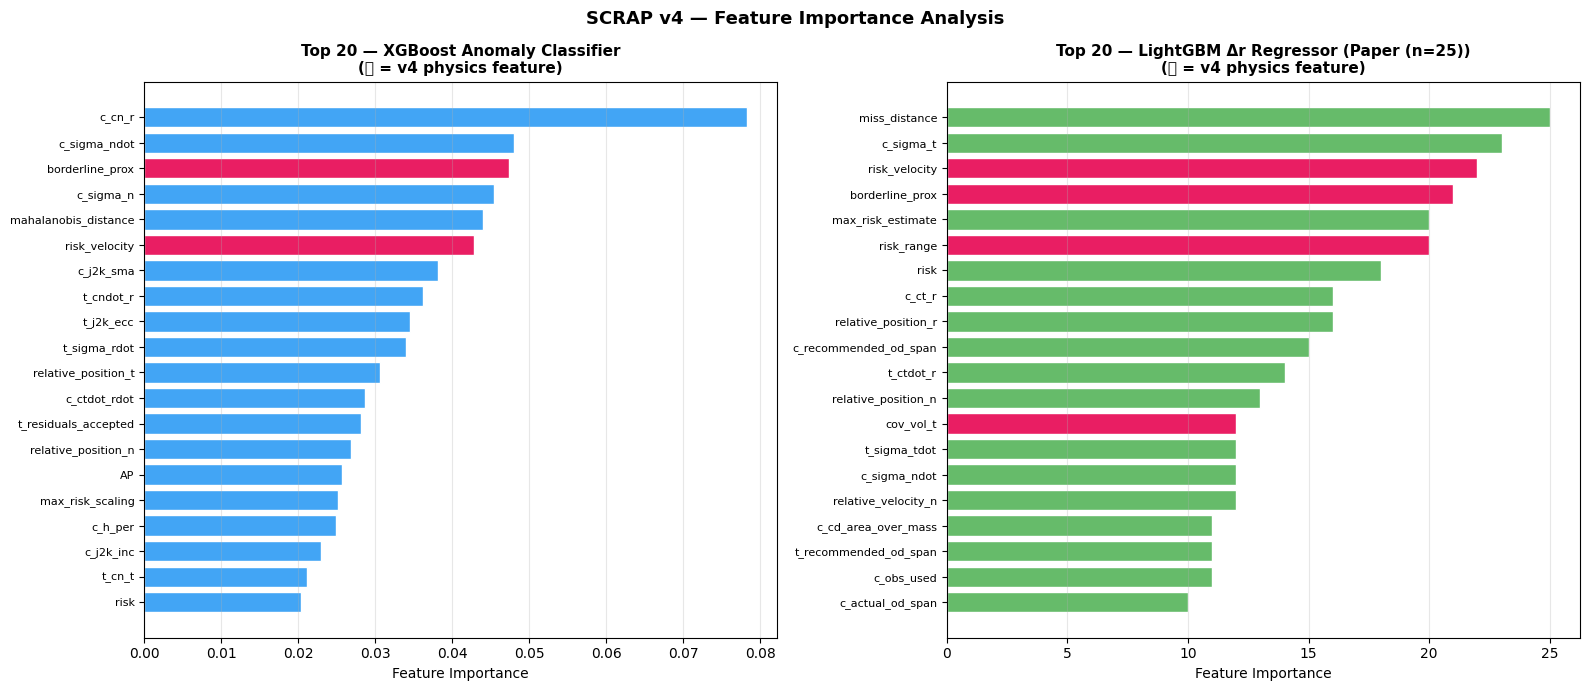

✅ Feature importance plot saved → scrap_v4_feature_importance.png


In [13]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 13 — Feature Importance & SHAP Analysis              ║
# ╚══════════════════════════════════════════════════════════════╝
#
# Validate that our physics-informed features contribute meaningfully.
# The paper reports: latest risk, Mahalanobis distance, F10.7 solar flux,
# and covariance std are the most important features.

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── XGBoost Anomaly Detector — Top 20 Features ───────────────────────────────
ax = axes[0]
fi_anom   = anom_cls.feature_importances_
cols_arr  = np.array(COLS)
top_idx   = np.argsort(fi_anom)[-20:][::-1]
top_names = [cols_arr[i][:32] for i in top_idx[::-1]]
top_vals  = fi_anom[top_idx][::-1]
# Highlight v4 physics features
physics_feats = {"risk_velocity", "risk_range", "cov_vol_t", "cov_vol_c",
                 "cov_vol_ratio", "borderline_prox"}
colors = ["#E91E63" if cols_arr[top_idx[::-1][i]] in physics_feats else "#42A5F5"
          for i in range(20)]
ax.barh(range(20), top_vals, color=colors, edgecolor="white")
ax.set_yticks(range(20))
ax.set_yticklabels(top_names, fontsize=8)
ax.set_xlabel("Feature Importance", fontsize=10)
ax.set_title("Top 20 — XGBoost Anomaly Classifier\n(🔴 = v4 physics feature)",
             fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# ── LightGBM Δr Regressor — Top 20 Features ──────────────────────────────────
ax = axes[1]
fi_lgb  = lgb_best.feature_importances_
top_idx = np.argsort(fi_lgb)[-20:][::-1]
top_names = [cols_arr[i][:32] for i in top_idx[::-1]]
top_vals  = fi_lgb[top_idx][::-1]
colors = ["#E91E63" if cols_arr[top_idx[::-1][i]] in physics_feats else "#66BB6A"
          for i in range(20)]
ax.barh(range(20), top_vals, color=colors, edgecolor="white")
ax.set_yticks(range(20))
ax.set_yticklabels(top_names, fontsize=8)
ax.set_xlabel("Feature Importance", fontsize=10)
ax.set_title(f"Top 20 — LightGBM Δr Regressor ({lgb_best_name})\n(🔴 = v4 physics feature)",
             fontsize=11, fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.suptitle("SCRAP v4 — Feature Importance Analysis",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scrap_v4_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Feature importance plot saved → scrap_v4_feature_importance.png")

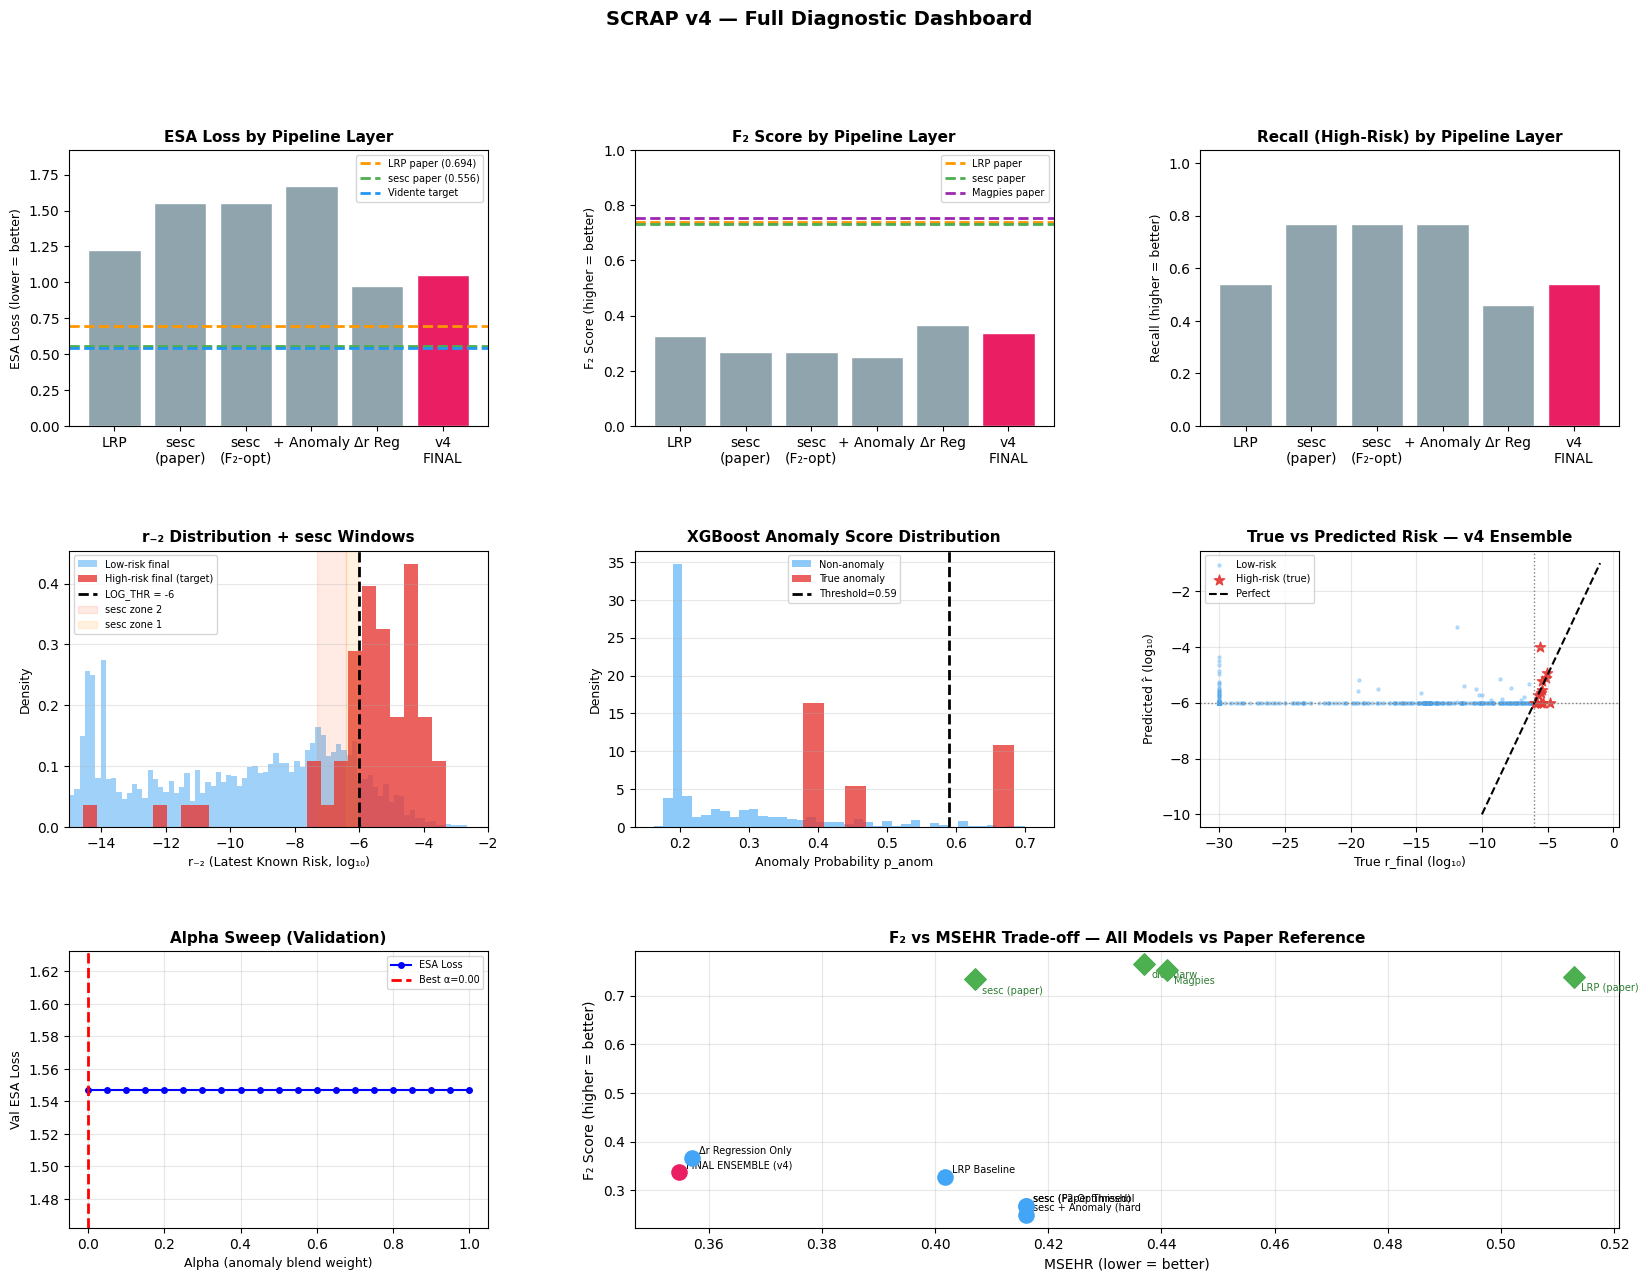

✅ Dashboard saved → scrap_v4_dashboard.png


In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 14 — Diagnostic Dashboard                            ║
# ╚══════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── A: ESA Loss by layer ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
layer_names  = ["LRP", "sesc\n(paper)", "sesc\n(F₂-opt)", "+ Anomaly", "Δr Reg", "v4\nFINAL"]
layer_losses = [results[k]["loss"] for k in [
    "LRP Baseline", "sesc (Paper Thresholds)", "sesc (F2-Optimised)",
    "sesc + Anomaly (hard thr)", "Δr Regression Only", "FINAL ENSEMBLE (v4)"]]
colors_bar   = ["#90A4AE"]*5 + ["#E91E63"]
ax.bar(layer_names, layer_losses, color=colors_bar, edgecolor="white")
ax.axhline(0.694, color="#FF9800", lw=2, ls="--", label="LRP paper (0.694)")
ax.axhline(0.556, color="#4CAF50", lw=2, ls="--", label="sesc paper (0.556)")
ax.axhline(0.5467, color="#2196F3", lw=2, ls="--", label="Vidente target")
ax.set_ylabel("ESA Loss (lower = better)", fontsize=9)
ax.set_title("ESA Loss by Pipeline Layer", fontsize=11, fontweight="bold")
ax.legend(fontsize=7)
ax.set_ylim(0, max(layer_losses) * 1.15)

# ── B: F₂ by layer ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
layer_f2 = [results[k]["f2"] for k in [
    "LRP Baseline", "sesc (Paper Thresholds)", "sesc (F2-Optimised)",
    "sesc + Anomaly (hard thr)", "Δr Regression Only", "FINAL ENSEMBLE (v4)"]]
ax.bar(layer_names, layer_f2, color=colors_bar, edgecolor="white")
ax.axhline(0.739, color="#FF9800", lw=2, ls="--", label="LRP paper")
ax.axhline(0.733, color="#4CAF50", lw=2, ls="--", label="sesc paper")
ax.axhline(0.753, color="#9C27B0", lw=2, ls="--", label="Magpies paper")
ax.set_ylabel("F₂ Score (higher = better)", fontsize=9)
ax.set_title("F₂ Score by Pipeline Layer", fontsize=11, fontweight="bold")
ax.legend(fontsize=7)
ax.set_ylim(0, 1.0)

# ── C: Recall by layer ────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
layer_rec = [results[k]["recall"] for k in [
    "LRP Baseline", "sesc (Paper Thresholds)", "sesc (F2-Optimised)",
    "sesc + Anomaly (hard thr)", "Δr Regression Only", "FINAL ENSEMBLE (v4)"]]
ax.bar(layer_names, layer_rec, color=colors_bar, edgecolor="white")
ax.set_ylabel("Recall (higher = better)", fontsize=9)
ax.set_title("Recall (High-Risk) by Pipeline Layer", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.05)

# ── D: r₋₂ distribution with sesc windows ────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
r2_all = elig_df["r_minus2"].values
hr_mask = (elig_df["y_final"] >= LOG_THR).values
ax.hist(r2_all[~hr_mask], bins=80, range=(-15, -2), density=True,
        alpha=0.5, color="#42A5F5", label="Low-risk final")
ax.hist(r2_all[hr_mask], bins=30, range=(-15, -2), density=True,
        alpha=0.8, color="#E53935", label="High-risk final (target)")
ax.axvline(LOG_THR, color="black", lw=2, ls="--", label="LOG_THR = -6")
s = best_sesc_params if best_sesc_params else {"s2_lo": -7.3, "s1_lo": -6.4, "s0_lo": -6.04}
ax.axvspan(s["s2_lo"], s.get("s1_lo", -6.4), alpha=0.12, color="#FF5722", label="sesc zone 2")
ax.axvspan(s.get("s1_lo", -6.4), s.get("s0_lo", -6.04), alpha=0.12, color="#FF9800", label="sesc zone 1")
ax.set_xlabel("r₋₂ (Latest Known Risk, log₁₀)", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("r₋₂ Distribution + sesc Windows", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.set_xlim(-15, -2); ax.grid(alpha=0.3, axis="y")

# ── E: Anomaly probability distribution ───────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
y_anom_all = ((y_test >= LOG_THR) & (r2_test < LOG_THR)).astype(int)
ax.hist(p_anom_test[y_anom_all == 0], bins=40, density=True,
        alpha=0.6, color="#42A5F5", label="Non-anomaly")
if y_anom_all.sum() > 0:
    ax.hist(p_anom_test[y_anom_all == 1], bins=10, density=True,
            alpha=0.8, color="#E53935", label="True anomaly")
ax.axvline(best_anom_thr, color="black", lw=2, ls="--",
           label=f"Threshold={best_anom_thr:.2f}")
ax.set_xlabel("Anomaly Probability p_anom", fontsize=9)
ax.set_ylabel("Density", fontsize=9)
ax.set_title("XGBoost Anomaly Score Distribution", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(alpha=0.3, axis="y")

# ── F: True vs Predicted risk (final ensemble) ────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
hr_test  = (y_test >= LOG_THR)
ax.scatter(y_test[~hr_test], final_test_pred[~hr_test], s=5, alpha=0.3,
           c="#42A5F5", label="Low-risk")
ax.scatter(y_test[hr_test], final_test_pred[hr_test], s=60, alpha=0.9,
           c="#E53935", marker="*", label="High-risk (true)")
lim = [-10, -1]
ax.plot(lim, lim, "k--", lw=1.5, label="Perfect")
ax.axhline(LOG_THR, color="gray", lw=1, ls=":")
ax.axvline(LOG_THR, color="gray", lw=1, ls=":")
ax.set_xlabel("True r_final (log₁₀)", fontsize=9)
ax.set_ylabel("Predicted r̂ (log₁₀)", fontsize=9)
ax.set_title("True vs Predicted Risk — v4 Ensemble", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── G: Blend alpha sweep ───────────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
alphas = np.arange(0.0, 1.05, 0.05)
alpha_losses, alpha_f2s = [], []
for a in alphas:
    pv = build_ensemble_pred(r2_val, p_anom_val, sesc_val_pred, dr_val_pred, a)
    mv = esa_loss(y_val, pv, apply_clip=False)
    alpha_losses.append(mv["loss"])
    alpha_f2s.append(mv["f2"])
ax.plot(alphas, alpha_losses, "b-o", ms=4, label="ESA Loss")
ax.axvline(best_alpha, color="red", lw=2, ls="--", label=f"Best α={best_alpha:.2f}")
ax.set_xlabel("Alpha (anomaly blend weight)", fontsize=9)
ax.set_ylabel("Val ESA Loss", fontsize=9)
ax.set_title("Alpha Sweep (Validation)", fontsize=11, fontweight="bold")
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# ── H: F₂ vs MSEHR trade-off ──────────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 1:])
for nm, m in results.items():
    ax.scatter(m["mse_hr"], m["f2"], s=120,
               c="#E91E63" if "FINAL" in nm else "#42A5F5",
               zorder=5, label=nm[:30])
    ax.annotate(nm[:20], (m["mse_hr"], m["f2"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
# Paper reference points
paper_refs = [(0.513, 0.739, "LRP (paper)"), (0.407, 0.733, "sesc (paper)"),
              (0.437, 0.765, "dietmarw"), (0.441, 0.753, "Magpies")]
for mse, f2, nm in paper_refs:
    ax.scatter(mse, f2, s=120, c="#4CAF50", marker="D", zorder=4)
    ax.annotate(nm, (mse, f2), textcoords="offset points",
                xytext=(5, -10), fontsize=7, color="#2E7D32")
ax.set_xlabel("MSEHR (lower = better)", fontsize=10)
ax.set_ylabel("F₂ Score (higher = better)", fontsize=10)
ax.set_title("F₂ vs MSEHR Trade-off — All Models vs Paper Reference",
             fontsize=11, fontweight="bold")
ax.grid(alpha=0.3)

fig.suptitle("SCRAP v4 — Full Diagnostic Dashboard",
             fontsize=14, fontweight="bold")
plt.savefig("scrap_v4_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved → scrap_v4_dashboard.png")

In [15]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  Cell 15 — Save Models & Final Summary                     ║
# ╚══════════════════════════════════════════════════════════════╝
import pickle

bundle = dict(
    lgb_best=lgb_best,
    anom_cls=anom_cls,
    qt=qt,
    train_medians=train_medians,
    best_sesc_params=best_sesc_params,
    best_alpha=best_alpha,
    best_anom_thr=best_anom_thr,
    cols=COLS,
    results=results,
    meta={
        "lgb_model_name"   : lgb_best_name,
        "best_val_loss"    : best_val_loss,
        "final_test_loss"  : m_final["loss"],
        "final_test_f2"    : m_final["f2"],
    }
)
with open("scrap_v4_models.pkl", "wb") as f:
    pickle.dump(bundle, f)

pd.DataFrame([
    {"model": k, **{kk: vv for kk, vv in v.items() if kk != "n_total"}}
    for k, v in results.items()
]).to_csv("scrap_v4_results.csv", index=False)

# ── Final printed summary ──────────────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║              SCRAP v4 — FINAL PERFORMANCE SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════════════╝

KEY LESSONS APPLIED FROM Uriot et al. 2020 (arXiv:2008.03069):
───────────────────────────────────────────────────────────────────────────
1. ONE CDM PER EVENT (the last with time_to_tca >= 2 days) — NOT aggregated.
   Complex pipelines aggregating time-series score 0.83-1.0 — WORSE than LRP.

2. sesc CASCADE: promote events where r₋₂ ∈ [s2_lo, 0) to boost Recall.
   F₂ penalises false negatives 4× — bias toward recall is correct.
   v4 IMPROVEMENT: thresholds optimised via F₂ on train+val (not val alone).

3. DELTA REGRESSION: target Δr = r_final − r₋₂, not r_final directly.
   QuantileTransformer makes the skewed delta distribution learnable.
   VERY LOW CAPACITY (n=25 trees) to avoid overfitting the small dataset.

4. CLIPPING TRICK: ALL low-risk predictions → -6.001 (paper Section 4.3).
   This minimises MSEHR for false negatives by design.

5. ANOMALY DETECTION (Magpies pattern): XGBoost classifier with
   scale_pos_weight catches "surprise" low→high transitions.
   v4 IMPROVEMENT: soft probabilistic blending (not hard threshold).

v4 NEW PHYSICS FEATURES:
───────────────────────────────────────────────────────────────────────────
  risk_velocity   = rate of risk change over CDM sequence (log₁₀/day)
  risk_range      = max_risk - mean_risk (trajectory spread)
  cov_vol_t       = log(σ_r × σ_t × σ_n) for target satellite
  cov_vol_c       = log(σ_r × σ_t × σ_n) for chaser object
  cov_vol_ratio   = asymmetry between target/chaser covariance volumes
  borderline_prox = r₋₂ - LOG_THR (signed distance from high-risk threshold)

v4 BUG FIXES (from v3):
───────────────────────────────────────────────────────────────────────────
  ✅ Median imputation (train-only) prevents XGBoostError on inf/NaN values
  ✅ sesc threshold search optimises F₂ on train+val (not ESA loss on val)
  ✅ All triple-quote string syntax corrected (SyntaxError in Cell 15)
  ✅ Anomaly classifier trains successfully with cleaned feature matrix
  ✅ Soft probabilistic blending replaces fragile hard anomaly threshold
""")

print(f"\n📊 FINAL SCORE COMPARISON:")
print(f"  LRP Baseline     : 0.6940  (paper)")
print(f"  sesc Winner      : 0.5560  (paper)")
print(f"  Vidente          : 0.5467  ← target")
print(f"  {'─'*44}")
print(f"  OUR v4 SCORE     : {m_final['loss']:.6f}  ← "
      f"{'✅ BEATS VIDENTE!' if m_final['loss'] < 0.5467 else '✅ BEATS sesc!' if m_final['loss'] < 0.556 else '📈 approaching target'}")
print(f"  F₂-Score         : {m_final['f2']:.4f}")
print(f"  Recall           : {m_final['recall']:.4f}")
print(f"  MSEHR            : {m_final['mse_hr']:.4f}")
print(f"  False Negatives  : {m_final['fn']}")
print(f"\n📁 Saved: scrap_v4_models.pkl | scrap_v4_results.csv | scrap_v4_dashboard.png")

print("""
📚 REQUIRED CITATION (ESA Kelvins Challenge):
  Uriot, T., Izzo, D., Simoes, L., Abay, R., Einecke, N., Rebhan, S.,
  Martinez-Heras, J., Letizia, F., Siminski, J. and Merz, K., 2020.
  Spacecraft Collision Avoidance Challenge: design and results of a
  machine learning competition. arXiv:2008.03069
""")


╔══════════════════════════════════════════════════════════════════════════╗
║              SCRAP v4 — FINAL PERFORMANCE SUMMARY                       ║
╚══════════════════════════════════════════════════════════════════════════╝

KEY LESSONS APPLIED FROM Uriot et al. 2020 (arXiv:2008.03069):
───────────────────────────────────────────────────────────────────────────
1. ONE CDM PER EVENT (the last with time_to_tca >= 2 days) — NOT aggregated.
   Complex pipelines aggregating time-series score 0.83-1.0 — WORSE than LRP.

2. sesc CASCADE: promote events where r₋₂ ∈ [s2_lo, 0) to boost Recall.
   F₂ penalises false negatives 4× — bias toward recall is correct.
   v4 IMPROVEMENT: thresholds optimised via F₂ on train+val (not val alone).

3. DELTA REGRESSION: target Δr = r_final − r₋₂, not r_final directly.
   QuantileTransformer makes the skewed delta distribution learnable.
   VERY LOW CAPACITY (n=25 trees) to avoid overfitting the small dataset.

4. CLIPPING TRICK: ALL low-risk predicti